In [1]:
!git clone https://github.com/KoushalyaSG/Global-Income-Inequality-Model.git

Cloning into 'Global-Income-Inequality-Model'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 69 (delta 17), reused 29 (delta 7), pack-reused 26 (from 1)
Receiving objects: 100% (69/69), 1.13 MiB | 8.72 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [24]:
df = pd.read_csv('/content/Global-Income-Inequality-Model/data/processed/validated_dataset.csv')
print("Dataset Loaded!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
df.head()

Dataset Loaded!
   Shape: (6500, 17)
   Columns: ['Year', 'Gini_Index', 'Education_Spending_%GDP', 'Unemployment_%', 'Country_Canada', 'Country_China', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Indonesia', 'Country_Japan', 'Country_South Africa', 'Country_UK', 'Country_USA', 'Education_Efficiency', 'Edu_to_Unemp_Ratio', 'Economic_Stress_Index']


,Year,Gini_Index,Education_Spending_%GDP,Unemployment_%,Country_Canada,Country_China,Country_France,Country_Germany,Country_India,Country_Indonesia,Country_Japan,Country_South Africa,Country_UK,Country_USA,Education_Efficiency,Edu_to_Unemp_Ratio,Economic_Stress_Index
0,2015,0.842549,0.527072,-0.268673,False,False,False,False,False,False,False,False,False,False,0.625568,-1.961766,0.573875
1,2017,-0.999993,0.407309,0.489238,False,False,False,False,True,False,False,False,False,False,-0.407313,0.832537,-0.510755
2,2004,-0.869453,-0.625874,-1.172062,False,False,False,False,False,False,False,False,False,False,0.719848,0.533994,-2.041516
3,2021,0.879966,-0.630030,0.006374,False,False,False,False,False,False,False,False,False,False,-0.715970,-98.824948,0.886341
4,2003,-0.258727,-0.572135,0.082963,False,False,False,False,True,False,False,False,False,False,2.211357,-6.896215,-0.175764


In [25]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

print("\nEDA Complete!")

=== Data Types ===
Year                         int64
Gini_Index                 float64
Education_Spending_%GDP    float64
Unemployment_%             float64
Country_Canada                bool
Country_China                 bool
Country_France                bool
Country_Germany               bool
Country_India                 bool
Country_Indonesia             bool
Country_Japan                 bool
Country_South Africa          bool
Country_UK                    bool
Country_USA                   bool
Education_Efficiency       float64
Edu_to_Unemp_Ratio         float64
Economic_Stress_Index      float64
dtype: object

=== Statistical Summary ===
              Year    Gini_Index  Education_Spending_%GDP  Unemployment_%  \
count  6500.000000  6.500000e+03             6.500000e+03    6.500000e+03   
mean   2011.576462 -7.695724e-16             7.608273e-16   -4.285119e-16   
std       6.917234  1.000077e+00             1.000077e+00    1.000077e+00   
min    2000.000000 -3.674460e+00   

In [26]:
num_cols = ['Gini_Index', 'Education_Spending_%GDP', 'Unemployment_%']

rows_before = len(df)
df_clean = df.dropna().copy()
print(f"Removed {rows_before - len(df_clean)} missing rows")


rows_before = len(df_clean)
z_scores = np.abs(stats.zscore(df_clean[num_cols]))
df_clean = df_clean[(z_scores < 3).all(axis=1)].copy()
print(f"Removed {rows_before - len(df_clean)} outlier rows")
print(f"\nClean dataset has {len(df_clean)} rows")

Removed 0 missing rows
Removed 88 outlier rows

Clean dataset has 6412 rows


In [27]:
df_clean['Year'] = df_clean['Year'].astype(int)
max_year = df_clean['Year'].max()
min_year = max_year - 9

df_10yr = df_clean[df_clean['Year'] >= min_year].copy()


country_cols = [col for col in df_10yr.columns if col.startswith('Country_')]
df_10yr['Country'] = df_10yr[country_cols].idxmax(axis=1).str.replace('Country_', '')

print(f"Filtered to {min_year} – {max_year}")
print(f"   Rows     : {len(df_10yr)}")
print(f"   Countries: {df_10yr['Country'].nunique()} unique")

Filtered to 2014 – 2023
   Rows     : 2703
   Countries: 10 unique


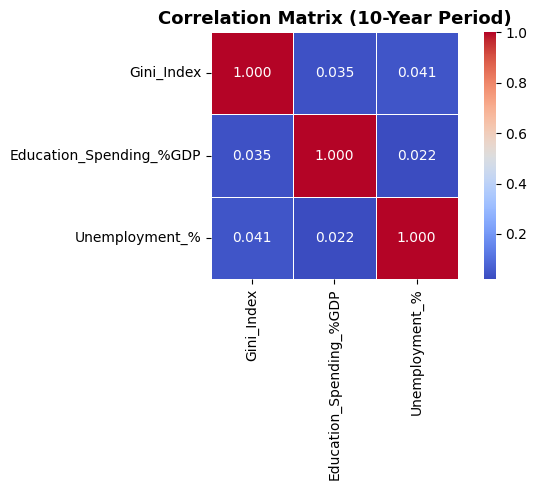


Correlation with Gini Index:
Education_Spending_%GDP    0.034533
Unemployment_%             0.041384
Name: Gini_Index, dtype: float64


In [16]:
plt.figure(figsize=(7, 5))
corr = df_10yr[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Matrix (10-Year Period)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Gini Index:")
print(corr['Gini_Index'].drop('Gini_Index'))

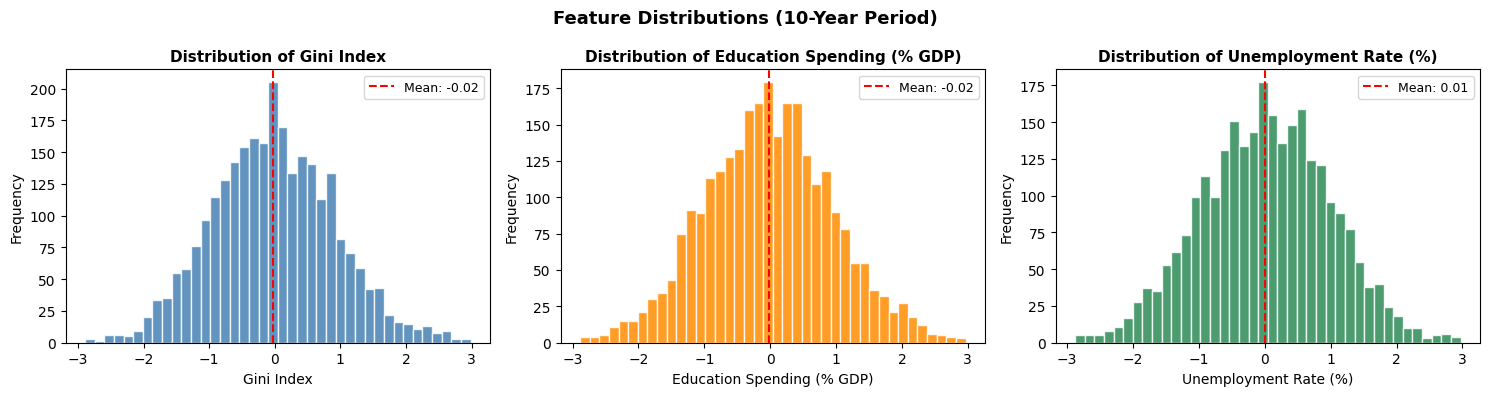

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'darkorange', 'seagreen']
titles = ['Gini Index', 'Education Spending (% GDP)', 'Unemployment Rate (%)']

for ax, col, color, title in zip(axes, num_cols, colors, titles):
    ax.hist(df_10yr[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_10yr[col].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean: {df_10yr[col].mean():.2f}')
    ax.set_title(f'Distribution of {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions (10-Year Period)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

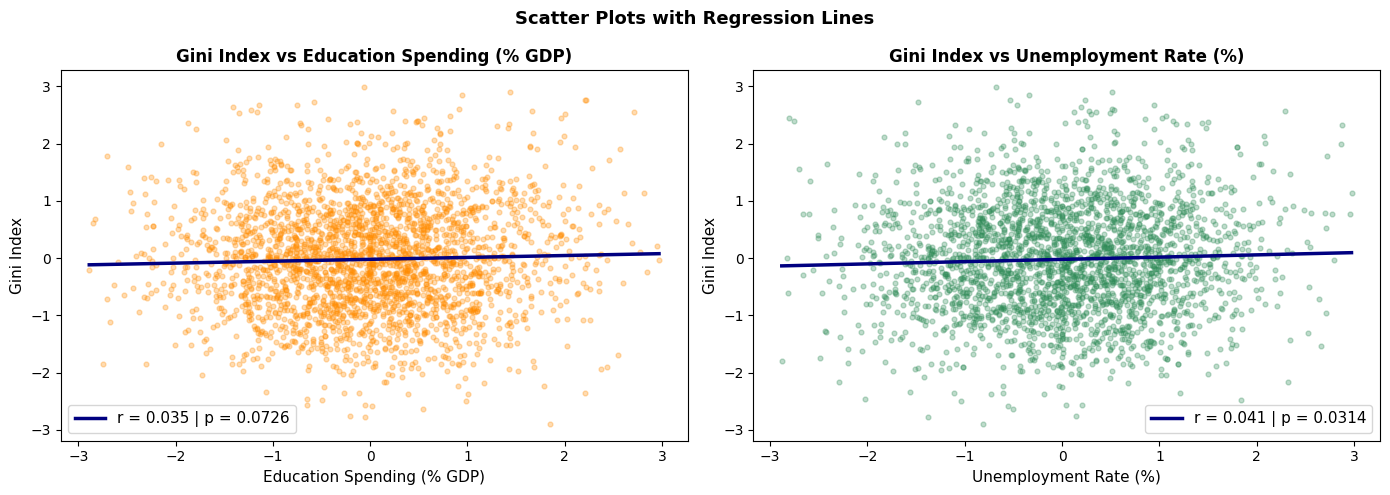

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, color, label in zip(
    axes,
    ['Education_Spending_%GDP', 'Unemployment_%'],
    ['darkorange', 'seagreen'],
    ['Education Spending (% GDP)', 'Unemployment Rate (%)']
):
    ax.scatter(df_10yr[feat], df_10yr['Gini_Index'], alpha=0.3, color=color, s=12)
    m, b, r, p, se = stats.linregress(df_10yr[feat], df_10yr['Gini_Index'])
    x_line = np.linspace(df_10yr[feat].min(), df_10yr[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, 'navy', linewidth=2.5, label=f'r = {r:.3f} | p = {p:.4f}')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Gini Index', fontsize=11)
    ax.set_title(f'Gini Index vs {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=11)

plt.suptitle('Scatter Plots with Regression Lines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
features = ['Education_Spending_%GDP', 'Unemployment_%']
target   = 'Gini_Index'

X = df_10yr[features]
y = df_10yr[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


model = LinearRegression()
model.fit(X_train, y_train)

print("\n=== Model Coefficients ===")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.6f}")
print(f"  Intercept: {model.intercept_:.6f}")

Training samples : 2162
Testing samples  : 541

=== Model Coefficients ===
  Education_Spending_%GDP: 0.020433
  Unemployment_%: 0.047187
  Intercept: -0.025211


In [20]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 45)
print("      MODEL PERFORMANCE (Test Set)")
print("=" * 45)
print(f"  R² Score : {r2:.4f}  ({r2*100:.2f}% variance explained)")
print(f"  RMSE     : {rmse:.4f}")
print(f"  MAE      : {mae:.4f}")
print("=" * 45)

      MODEL PERFORMANCE (Test Set)
  R² Score : 0.0005  (0.05% variance explained)
  RMSE     : 0.9164
  MAE      : 0.7142


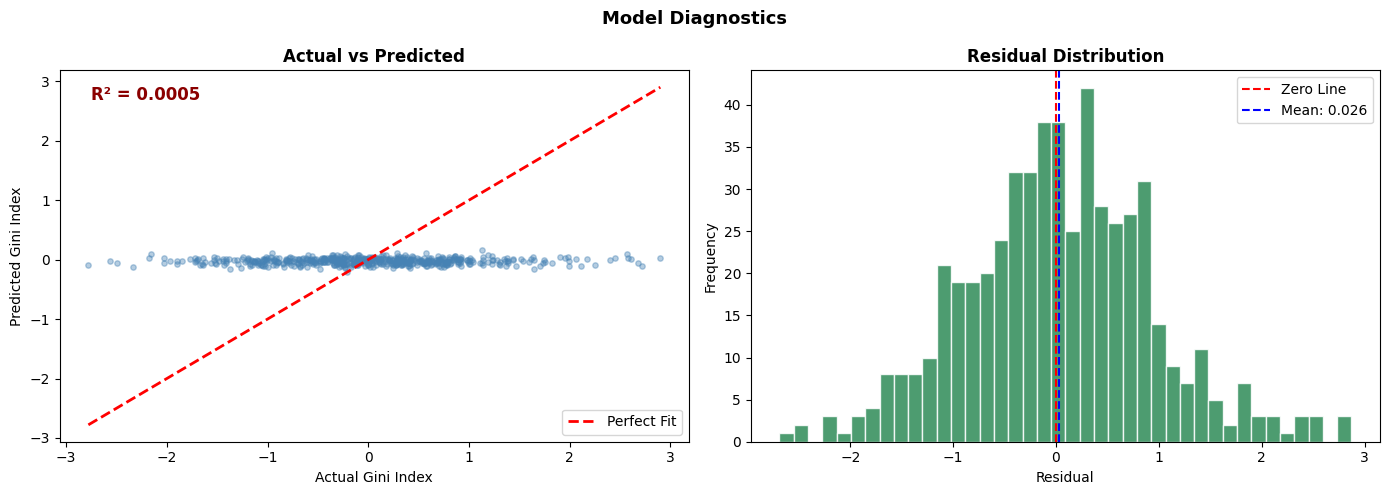

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Gini Index')
axes[0].set_ylabel('Predicted Gini Index')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, color='darkred', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Line')
axes[1].axvline(residuals.mean(), color='blue', linestyle='--',
                linewidth=1.5, label=f'Mean: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

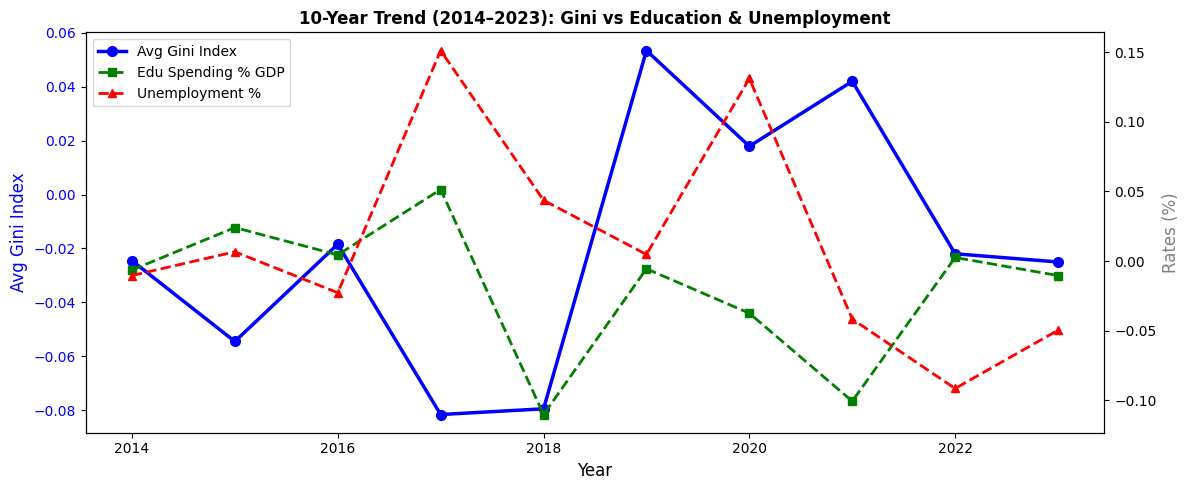

In [22]:
yearly = df_10yr.groupby('Year')[num_cols].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(yearly.index, yearly['Gini_Index'], 'b-o', linewidth=2.5,
         markersize=7, label='Avg Gini Index')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Avg Gini Index', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['Education_Spending_%GDP'], 'g--s',
         linewidth=2, markersize=6, label='Edu Spending % GDP')
ax2.plot(yearly.index, yearly['Unemployment_%'], 'r--^',
         linewidth=2, markersize=6, label='Unemployment %')
ax2.set_ylabel('Rates (%)', color='gray', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title(f'10-Year Trend ({min_year}–{max_year}): Gini vs Education & Unemployment',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
# New scenario predictions
new_data = pd.DataFrame({
    'Education_Spending_%GDP': [3.5, 5.0, 6.5, 8.0],
    'Unemployment_%':          [4.0, 6.5, 9.0, 12.0]
})
new_data['Predicted_Gini_Index'] = model.predict(new_data)
print("=== Predictions for New Scenarios ===")
print(new_data.to_string(index=False))

# Final summary
edu_dir   = 'INCREASES ↑' if model.coef_[0] > 0 else 'DECREASES ↓'
unemp_dir = 'INCREASES ↑' if model.coef_[1] > 0 else 'DECREASES ↓'

print("\n" + "=" * 55)
print("           FINAL MODEL SUMMARY")
print("=" * 55)
print(f"\n  Dataset Path : /content/Global-Income-Inequality-Model/")
print(f"                 data/processed/validated_dataset.csv")
print(f"  Period       : {min_year} – {max_year} (10 years)")
print(f"  Countries    : {df_10yr['Country'].nunique()} unique")
print(f"\n  Regression Equation:")
print(f"  Gini = {model.intercept_:.4f}", end="")
for feat, coef in zip(features, model.coef_):
    sign = '+' if coef >= 0 else '-'
    print(f" {sign} {abs(coef):.4f} × {feat}", end="")
print(f"\n\n  R²   = {r2:.4f}  ({r2*100:.2f}% variance explained)")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")
print(f"\n  📌 1% ↑ Education Spending → Gini {edu_dir} by {abs(model.coef_[0]):.4f}")
print(f"  📌 1% ↑ Unemployment       → Gini {unemp_dir} by {abs(model.coef_[1]):.4f}")
print("=" * 55)

=== Predictions for New Scenarios ===
 Education_Spending_%GDP  Unemployment_%  Predicted_Gini_Index
                     3.5             4.0              0.235054
                     5.0             6.5              0.383672
                     6.5             9.0              0.532290
                     8.0            12.0              0.704502

           FINAL MODEL SUMMARY

  Dataset Path : /content/Global-Income-Inequality-Model/
                 data/processed/validated_dataset.csv
  Period       : 2014 – 2023 (10 years)
  Countries    : 10 unique

  Regression Equation:
  Gini = -0.0252 + 0.0204 × Education_Spending_%GDP + 0.0472 × Unemployment_%

  R²   = 0.0005  (0.05% variance explained)
  RMSE = 0.9164
  MAE  = 0.7142

  📌 1% ↑ Education Spending → Gini INCREASES ↑ by 0.0204
  📌 1% ↑ Unemployment       → Gini INCREASES ↑ by 0.0472
